## Functions in `plt`

Matplotlib's `pyplot` module is usually imported as `plt`.

This notebook explains the most commonly used `plt` functions with examples based on `student_depression_dataset.csv`.

### 0. Common plotting parameters

A lot of `plt` functions reuse the same kinds of parameters.

- `x` and `y`: data values to plot on the horizontal and vertical axes.
- `label`: the name shown in the legend.
- `color` or `c`: the color of the plot element.
- `marker`: the symbol used for each data point.
- `linewidth`: thickness of a line.
- `figsize`: size of the figure in inches, written as `(width, height)`.
- `bins`: number of bins in a histogram.
- `alpha`: transparency level, from 0 to 1.
- `rotation`: rotates tick labels.
- `autopct`: formats percentages in a pie chart.
- `startangle`: starting angle for a pie chart.
- `edgecolor`: border color of bars or histogram bins.
- `tight_layout()`: adjusts spacing so labels do not overlap.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

df = pd.read_csv('Datasets/student_depression_dataset.csv')
print(df.head())

### 1. What `plt` does

- `plt` helps create charts quickly.
- It controls the figure, axes, labels, ticks, legends, and layout.
- Most plotting workflows follow the same pattern: create a figure, draw a plot, decorate it, then show it.

### 2. `plt.plot()` and line charts

`plt.plot(x, y, ...)` is used for line plots and trend visualization.

Parameters used in the example:

- `x`: row number values from the DataFrame.
- `y`: `Age` values to draw the line.
- `marker='o'`: shows a circle at each data point.
- `linewidth=2`: makes the line thicker and easier to read.

Here we compare the first 20 `Age` values to see how a line chart is drawn from a dataset column.

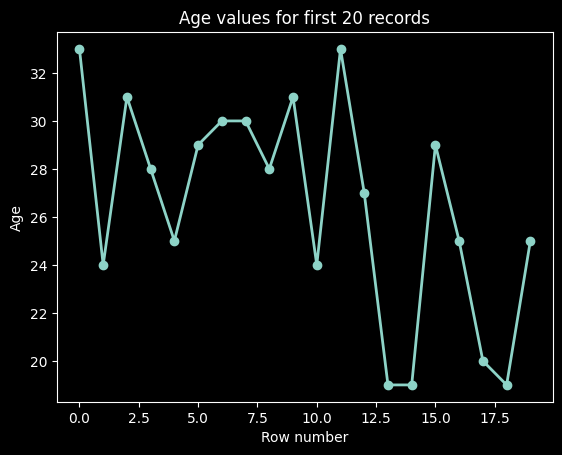

In [2]:
sample = df.head(20).reset_index(drop=True)

plt.plot(sample.index, sample['Age'], marker='o', linewidth=2)
plt.title('Age values for first 20 records')
plt.xlabel('Row number')
plt.ylabel('Age')
plt.show()

### 3. `plt.figure()` and `plt.gcf()`

- `plt.figure(figsize=(w, h))` creates a new figure window and controls its size.
- `plt.gcf()` returns the current figure.
- `plt.gca()` returns the current axes.

Parameters used in the example:

- `figsize=(8, 4)`: sets the width and height of the figure.

These are useful when you want to control the plot canvas before drawing charts.

Current figure: Figure(800x400)
Current axes: Axes(0.125,0.11;0.775x0.77)


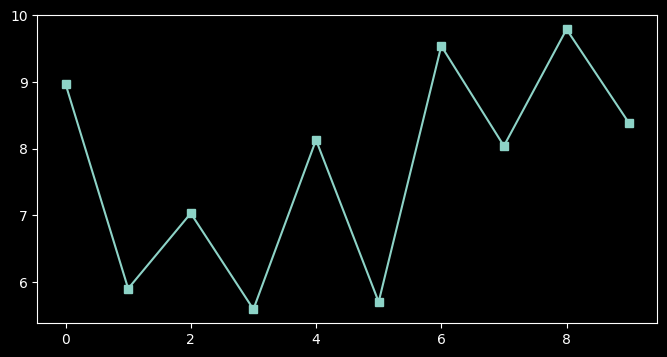

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(df.head(10)['CGPA'], marker='s')
print('Current figure:', plt.gcf())
print('Current axes:', plt.gca())
plt.show()

### 4. `plt.title()`, `plt.xlabel()`, and `plt.ylabel()`

These functions add text to the chart so the graph is easier to understand.

Parameters used in the example:

- `title(text)`: adds the main heading for the figure.
- `xlabel(text)`: names the horizontal axis.
- `ylabel(text)`: names the vertical axis.

You can also use optional text formatting parameters such as `fontsize`, `color`, and `pad`.

In [ ]:
plt.plot(df.head(15)['Work/Study Hours'])
plt.title('Work/Study Hours for first 15 rows')
plt.xlabel('Observation')
plt.ylabel('Hours')
plt.show()

### 5. `plt.legend()` and `plt.grid()`

- `legend()` explains multiple lines or categories.
- `grid()` makes values easier to read across the chart.

Parameters used in the example:

- `label`: gives each plotted line a name for the legend.
- `grid(True)`: turns the grid on.

These are commonly used together in line plots.

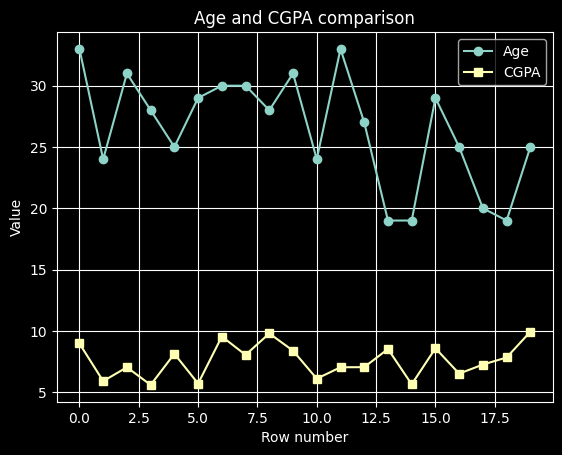

In [4]:
x = df.head(20).index
plt.plot(x, df.head(20)['Age'], marker='o', label='Age')
plt.plot(x, df.head(20)['CGPA'], marker='s', label='CGPA')
plt.title('Age and CGPA comparison')
plt.xlabel('Row number')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

### 6. `plt.xticks()`, `plt.yticks()`, `plt.xlim()`, and `plt.ylim()`

- `xticks()` and `yticks()` control tick labels.
- `xlim()` and `ylim()` control axis ranges.

Parameters used in the example:

- `rotation=0`: keeps x-axis labels horizontal.
- `range(...)`: defines the y-axis tick positions.
- `ylim(0, max + 1000)`: expands the vertical range for readability.

These functions are useful for formatting and focusing on specific ranges.

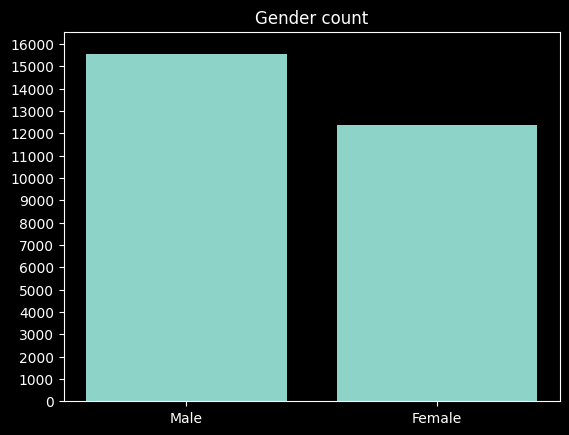

In [5]:
counts = df['Gender'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=0)
plt.yticks(range(0, counts.max() + 1000, 1000))
plt.ylim(0, counts.max() + 1000)
plt.title('Gender count')
plt.show()

### 7. `plt.text()` and `plt.annotate()`

- `text()` writes text at a specific position.
- `annotate()` points to a value and explains it.

Parameters used in the example:

- `x`, `y`: position where the text or arrow is placed.
- `fontsize`: size of the annotation text.
- `xy`: point being highlighted.
- `xytext`: location where the annotation text is shown.
- `arrowprops`: arrow style settings used to connect text to the point.

These are useful when you want to highlight a single value in a plot.

In [ ]:
city_counts = df['City'].value_counts().head(5)
plt.bar(city_counts.index, city_counts.values)
plt.title('Top 5 cities in the dataset')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.text(0, city_counts.values[0], 'Highest count city', fontsize=9)
plt.annotate('Peak', xy=(0, city_counts.values[0]), xytext=(0.3, city_counts.values[0] + 300), arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.show()

### 8. `plt.hist()`

`hist(data, bins=..., edgecolor=...)` shows the distribution of a numeric column.

Parameters used in the example:

- `data`: the numeric column being summarized.
- `bins=20`: splits the values into 20 intervals.
- `edgecolor='black'`: makes each bin boundary visible.

Here we use `Age` to understand how the values are spread in the dataset.

In [ ]:
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 9. `plt.bar()` and `plt.barh()`

- `bar(x, height, ...)` creates vertical bars.
- `barh(y, width, ...)` creates horizontal bars.

Parameters used in the example:

- `x` or `y`: category labels.
- `height` or `width`: numeric counts for each category.
- `rotation=45`: rotates labels so they fit.

They are best for category comparison.

In [ ]:
top_cities = df['City'].value_counts().head(5)

plt.bar(top_cities.index, top_cities.values)
plt.title('Top 5 cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

plt.barh(top_cities.index, top_cities.values)
plt.title('Top 5 cities - horizontal view')
plt.xlabel('Count')
plt.ylabel('City')
plt.show()

### 10. `plt.scatter()`

`scatter(x, y, ...)` shows the relationship between two numeric columns.

Parameters used in the example:

- `x`: `Age` values.
- `y`: `CGPA` values.
- `alpha=0.3`: makes overlapping points easier to see.

This example compares `Age` and `CGPA`.

In [ ]:
plt.scatter(df['Age'], df['CGPA'], alpha=0.3)
plt.title('Age vs CGPA')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

### 11. `plt.pie()`

`pie(values, labels=..., autopct=..., startangle=...)` shows proportions of a category.

Parameters used in the example:

- `values`: counts for each category.
- `labels`: category names.
- `autopct='%1.1f%%'`: displays percentage values on the chart.
- `startangle=90`: rotates the chart for a cleaner layout.

We use the `Gender` distribution here.

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender distribution')
plt.axis('equal')
plt.show()

### 12. `plt.subplot()` and `plt.subplots()`

- `subplot(nrows, ncols, index)` creates multiple plots inside one figure.
- `subplots(nrows, ncols, figsize=...)` is the cleaner modern way to create figure and axes together.

Parameters used in the example:

- `1, 2`: creates one row and two columns of plots.
- `figsize=(12, 4)`: gives enough space for both charts.

These functions are useful when you want to compare several charts side by side.

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Age'], bins=15, edgecolor='black')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['Age'], df['CGPA'], alpha=0.2)
axes[1].set_title('Age vs CGPA')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('CGPA')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### 13. `plt.style.use()` and formatting helpers

- `style.use(name)` changes the overall look of the plots.
- `tight_layout()` reduces overlap.
- `suptitle(text)` adds a title for the entire figure.

Parameters used in the example:

- `'ggplot'`: a built-in style preset.
- `text`: the title for the whole figure.

These functions improve readability.

In [ ]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Styled plots using Matplotlib')

axes[0].bar(top_cities.index, top_cities.values)
axes[0].set_title('Top cities')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df['Financial Stress'], bins=10, edgecolor='black')
axes[1].set_title('Financial Stress distribution')
axes[1].set_xlabel('Stress level')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 14. `plt.axhline()`, `plt.axvline()`, and `plt.fill_between()`

- `axhline(y, ...)` draws a horizontal reference line.
- `axvline(x, ...)` draws a vertical reference line.
- `fill_between(x, y1, y2, ...)` shades the area between two curves or values.

Parameters used in the example:

- `mean_age`: the horizontal threshold line.
- `10`: the vertical position used as a reference line.
- `alpha=0.15`: makes the shaded area transparent.

These helpers are useful for highlighting thresholds or ranges.

In [ ]:
age_series = df.head(30)['Age'].reset_index(drop=True)
mean_age = age_series.mean()

plt.plot(age_series, label='Age')
plt.axhline(mean_age, color='red', linestyle='--', label='Mean Age')
plt.axvline(10, color='green', linestyle=':', label='Row 10')
plt.fill_between(age_series.index, age_series, mean_age, alpha=0.15)
plt.title('Reference lines and shaded area')
plt.xlabel('Row number')
plt.ylabel('Age')
plt.legend()
plt.show()

### 15. `plt.clf()` and `plt.cla()`

- `clf()` clears the current figure.
- `cla()` clears the current axes.

Parameters: these functions do not require input parameters.

These are helpful when building multiple plots in one notebook cell.

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(df.head(10)['CGPA'])
plt.title('Before clearing')
plt.show()

plt.clf()
plt.figure(figsize=(5, 3))
plt.bar(gender_counts.index, gender_counts.values)
plt.title('After clearing and drawing again')
plt.show()

### 16. `plt.savefig()` and `plt.close()`

- `savefig(filename, ...)` saves the chart as an image file.
- `close(fig)` closes the current figure after saving or displaying it.

Parameters used in the example:

- `'gender_distribution.png'`: output image file name.
- `fig`: the specific figure object to close.

These are useful when generating charts for reports or notebooks.

In [ ]:
fig = plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index, gender_counts.values)
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.close(fig)
print('Figure saved as gender_distribution.png')

### 17. Study summary

The most important `plt` functions to remember are:

- `figure()`, `plot()`, `bar()`, `barh()`, `hist()`, `scatter()`, `pie()`
- `title()`, `xlabel()`, `ylabel()`, `legend()`, `grid()`
- `xticks()`, `yticks()`, `xlim()`, `ylim()`, `text()`, `annotate()`
- `subplot()`, `subplots()`, `tight_layout()`, `savefig()`, `close()`
- `axhline()`, `axvline()`, `fill_between()`, `clf()`, `cla()`

The dataset used throughout this notebook is `student_depression_dataset.csv`.

In [ ]:
print(df[['Gender', 'Age', 'City', 'CGPA', 'Depression']].head())